In [1]:
import numpy as np
import pandas as pd

In [2]:
# 1. Load the files
features = np.load('cifar10_features.npy')
labels = np.load('cifar10_labels.npy')

In [4]:
# 2. Create the DataFrame
df = pd.DataFrame(features, columns=[f'feature_{i}' for i in range(features.shape[1])])

In [5]:
# 3. Add the labels column
df['target'] = labels

In [6]:
# 4. Inspect the "table"  //just to see if its working can delete after finish
print(df.head())

   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0 -10.316492  -9.219499   5.683609  10.560703  -7.890817  -5.444539   
1   7.481172   6.139558   3.340362   0.086687  -0.778771  -8.864485   
2  11.439068   6.996174   0.529432   4.803377  -2.037642 -13.855770   
3  -0.202597  -1.290663   2.822140   7.991901  -5.137169   8.211122   
4  -4.336529  -6.523737   6.679166  -3.480664   5.330081  -7.831345   

   feature_6  feature_7  feature_8  feature_9  feature_10  feature_11  \
0 -13.386533   8.584426   1.237310   2.620596   11.018443   -4.234933   
1  -6.706285  -1.069057   4.987281   1.603810    6.423094   -0.742631   
2  -5.317335   2.130171  11.248181   6.665526   15.688234   -4.421451   
3   4.824665  -2.306614  -5.748542  -1.800817  -14.819701  -11.072560   
4 -16.029387   5.866822   2.586809   1.157517   -1.362694    3.455760   

   feature_12  feature_13  feature_14  feature_15  target  
0    5.095857    6.370559   -1.809084    7.222500       4  
1    2.594114 

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split

# Split into training and testing sets (70/30 esplit)
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
from sklearn.linear_model import LogisticRegression

# Softmax Model
softmax_model = LogisticRegression(

    solver='lbfgs',
    max_iter=1000
)



In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# one vs all model
ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))


In [18]:
import time
from sklearn.metrics import accuracy_score

def evaluate_model(model, name, X_train, y_train, X_test, y_test):
    # --- Measure Training Time ---
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    end_train = time.perf_counter()
    train_time = end_train - start_train

    # --- Measure Prediction (Inference) Time ---
    start_pred = time.perf_counter()
    predictions = model.predict(X_test)
    end_pred = time.perf_counter()
    pred_time = end_pred - start_pred

    # --- Calculate Success Rate (Accuracy) ---
    accuracy = accuracy_score(y_test, predictions)

    return {
        "Model": name,
        "Accuracy (%)": accuracy * 100,
        "Train Time (s)": train_time,
        "Inference Time (s)": pred_time
    }

# Run the evaluation for both
softmax_results = evaluate_model(softmax_model, "Softmax", X_train, y_train, X_test, y_test)
ovr_results = evaluate_model(ovr_model, "One-vs-All", X_train, y_train, X_test, y_test)

# Display the results in a clean table
results_df = pd.DataFrame([softmax_results, ovr_results])
print(results_df)

        Model  Accuracy (%)  Train Time (s)  Inference Time (s)
0     Softmax          96.3        1.020607            0.002142
1  One-vs-All          96.1        0.376322            0.009127


In [19]:
from sklearn.metrics import log_loss

# 1. Get the probability scores (instead of hard 0 or 1 predictions)
softmax_probs = softmax_model.predict_proba(X_test)
ovr_probs = ovr_model.predict_proba(X_test)

# 2. Calculate the Cost (Log Loss)
softmax_cost = log_loss(y_test, softmax_probs)
ovr_cost = log_loss(y_test, ovr_probs)

print(f"Softmax Cost: {softmax_cost:.4f}")
print(f"One-vs-All Cost: {ovr_cost:.4f}")

Softmax Cost: 0.1077
One-vs-All Cost: 0.1346


In [21]:
from sklearn.metrics import f1_score, classification_report

# 1. Get predictions from your models
softmax_preds = softmax_model.predict(X_test)
ovr_preds = ovr_model.predict(X_test)

# 2. Calculate the F1-score
# Use 'weighted' or 'macro' for multi-class data
softmax_f1 = f1_score(y_test, softmax_preds, average='weighted')
ovr_f1 = f1_score(y_test, ovr_preds, average='weighted')

print(f"Softmax F1-Score: {softmax_f1:.4f}")
print(f"One-vs-All F1-Score: {ovr_f1:.4f}")

# 3. Get the full report (highly recommended)   remember to delete as it was not asked but i wanted to see
print("\nSoftmax Detailed Report:")
print(classification_report(y_test, softmax_preds))

print("\none vs many Detailed Report:")
print(classification_report(y_test, ovr_preds))

Softmax F1-Score: 0.9630
One-vs-All F1-Score: 0.9610

Softmax Detailed Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1464
           1       0.99      0.99      0.99      1485
           2       0.95      0.95      0.95      1440
           3       0.92      0.93      0.93      1569
           4       0.97      0.96      0.96      1519
           5       0.94      0.94      0.94      1534
           6       0.98      0.97      0.97      1463
           7       0.97      0.97      0.97      1497
           8       0.98      0.98      0.98      1510
           9       0.98      0.98      0.98      1519

    accuracy                           0.96     15000
   macro avg       0.96      0.96      0.96     15000
weighted avg       0.96      0.96      0.96     15000


one vs many Detailed Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1464
           1       0.98

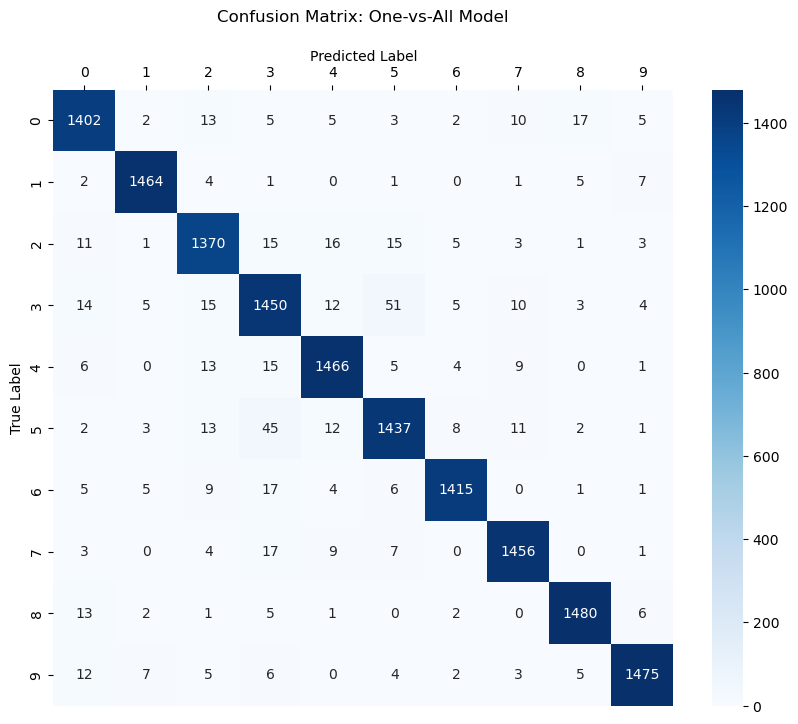

Most frequent mistake: 51 at Actual 3, Predicted 5


In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt



# 1. Create the confusion matrix
# This compares the True labels (y_test) vs Predicted labels (ovr_preds)
cm = confusion_matrix(y_test, ovr_preds)

# 2. Plot the matrix
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))

# Move X-axis ticks (the numbers 0-9) to the top
ax.xaxis.tick_top()

# Move the X-axis label ("Predicted Label") to the top
ax.xaxis.set_label_position('top')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: One-vs-All Model', pad=20) # Added padding so it doesn't overlap
plt.show()

# Initialize max_val with a very small number or 0
max_val = 0
max_indices = (0, 0)

for i in range(10):
    for j in range(10):
        # We only care about the off-diagonal (the mistakes)
        if i != j:
            # In your matrix 'ax' refers to the array of values
            if cm[i, j] > max_val:
                max_val = cm[i, j]
                max_indices = (i, j)

print(f"Most frequent mistake: {max_val} at Actual {max_indices[0]}, Predicted {max_indices[1]}")

In [25]:
# Create a mask for rows that are either 3 or 5
mask = (labels == 3) | (labels == 5)

# Filter the dataset
X_expert = features[mask]
y_expert = labels[mask]

# Optional: Map labels to 0 and 1 for the binary model
# 3 -> 0, 5 -> 1
y_expert_binary = np.where(y_expert == 3, 0, 1)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Split the 3rd/5th specific data
X_train_ex, X_test_ex, y_train_ex, y_test_ex = train_test_split(
    X_expert, y_expert_binary, test_size=0.2, random_state=42
)

# Train the expert model
expert_model = LogisticRegression(max_iter=1000)
expert_model.fit(X_train_ex, y_train_ex)

print(f"Expert Model Accuracy (3 vs 5): {expert_model.score(X_test_ex, y_test_ex):.4f}")

Expert Model Accuracy (3 vs 5): 0.9655


In [35]:
import pandas as pd
import warnings

def final_prediction(image_data):
    # Convert input to a numpy array to remove feature names
    # This prevents 'X has feature names' vs 'X does not have names' conflicts
    if isinstance(image_data, (pd.DataFrame, pd.Series)):
        input_data = image_data.values.reshape(1, -1)
    else:
        input_data = image_data.reshape(1, -1)

    # Use the main model (trained with names) - it will accept raw numbers with a warning,
    # unless we suppress it or wrap it back. To be 100% clean:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        initial_pred = softmax_model.predict(input_data)[0]

        if initial_pred in [3, 5]:
            # The expert model (trained without names) gets raw numbers here
            expert_binary_pred = expert_model.predict(input_data)[0]
            final_pred = 3 if expert_binary_pred == 0 else 5
            return final_pred

    return initial_pred



Final Decision: 5


In [38]:
import pandas as pd
import numpy as np
import warnings

# 1. Silence warnings and feature name requirements
warnings.filterwarnings('ignore', category=UserWarning)
softmax_model.feature_names_in_ = None
ovr_model.feature_names_in_ = None
if hasattr(expert_model, 'feature_names_in_'):
    expert_model.feature_names_in_ = None

# 2. Get predictions from One-vs-All
ovr_preds = ovr_model.predict(X_test.values)

# 3. Create a strict mask for cross-confusion only (the 96 mistakes)
# (Actual is 3 AND Pred is 5) OR (Actual is 5 AND Pred is 3)
cross_mistake_mask = ((y_test == 3) & (ovr_preds == 5)) | ((y_test == 5) & (ovr_preds == 3))
mistake_indices = y_test[cross_mistake_mask].index

print(f"Total Cross-Confusion mistakes (3 vs 5): {len(mistake_indices)}")

# 4. Run the Expert Model comparison
ovr_correct = 0
expert_correct = 0

for idx in mistake_indices:
    actual = y_test.loc[idx]
    row_data = X_test.loc[idx].values.reshape(1, -1)

    # Baseline check (Will be 0 because we only picked mistakes)
    ovr_pred = ovr_model.predict(row_data)[0]
    if ovr_pred == actual:
        ovr_correct += 1

    # Expert check: Map binary 0/1 back to 3/5
    expert_binary = expert_model.predict(row_data)[0]
    expert_pred = 3 if expert_binary == 0 else 5

    if expert_pred == actual:
        expert_correct += 1

# 5. Final Results
print("-" * 35)
print(f"One-vs-All Correct: {ovr_correct} / {len(mistake_indices)}")
print(f"Expert Model Correct: {expert_correct} / {len(mistake_indices)}")
print(f"Success Rate on the 96 errors: {(expert_correct/len(mistake_indices))*100:.2f}%")

Total Cross-Confusion mistakes (3 vs 5): 96
-----------------------------------
One-vs-All Correct: 0 / 96
Expert Model Correct: 4 / 96
Success Rate on the 96 errors: 4.17%
